In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from devmap.utils import save_plot
from devmap.config import set_theme, discrete_cmap

In [2]:
df = pd.read_csv("distributional_metrics/pairwise_clone_distributional_distances.csv")

In [3]:
def to_symmetric_matrix(df_pw, value_col, order):
    """Aggregate batches to mean, then fill both triangles."""
    agg = df_pw.groupby(["clone_a", "clone_b"])[value_col].mean()
    idx = {e: k for k, e in enumerate(order)}
    mat = pd.DataFrame(np.nan, index=order, columns=order)
    for (a, b), v in agg.items():
        mat.iloc[idx[a], idx[b]] = v
        mat.iloc[idx[b], idx[a]] = v
    np.fill_diagonal(mat.values, 0.0)
    return mat

mat = to_symmetric_matrix(df, "sinkhorn", np.unique(df[["clone_a", "clone_b"]].values.flatten()))

In [4]:
e95_clones = [c for c in mat.columns if "E9.5" in c]

e95_mat = mat.loc[e95_clones, e95_clones]

In [5]:
import matplotlib.colors as mcolors

import re

def sort_key(label):
    # e.g. "E8.5-R2-clone3" -> (8.5, 'R2', 'clone3')
    parts = label.split("-")
    num = float(re.search(r"[\d.]+", parts[0]).group())
    return (num, *parts[1:])

order = sorted(mat.index, key=sort_key)
mat = mat.loc[order, order]

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

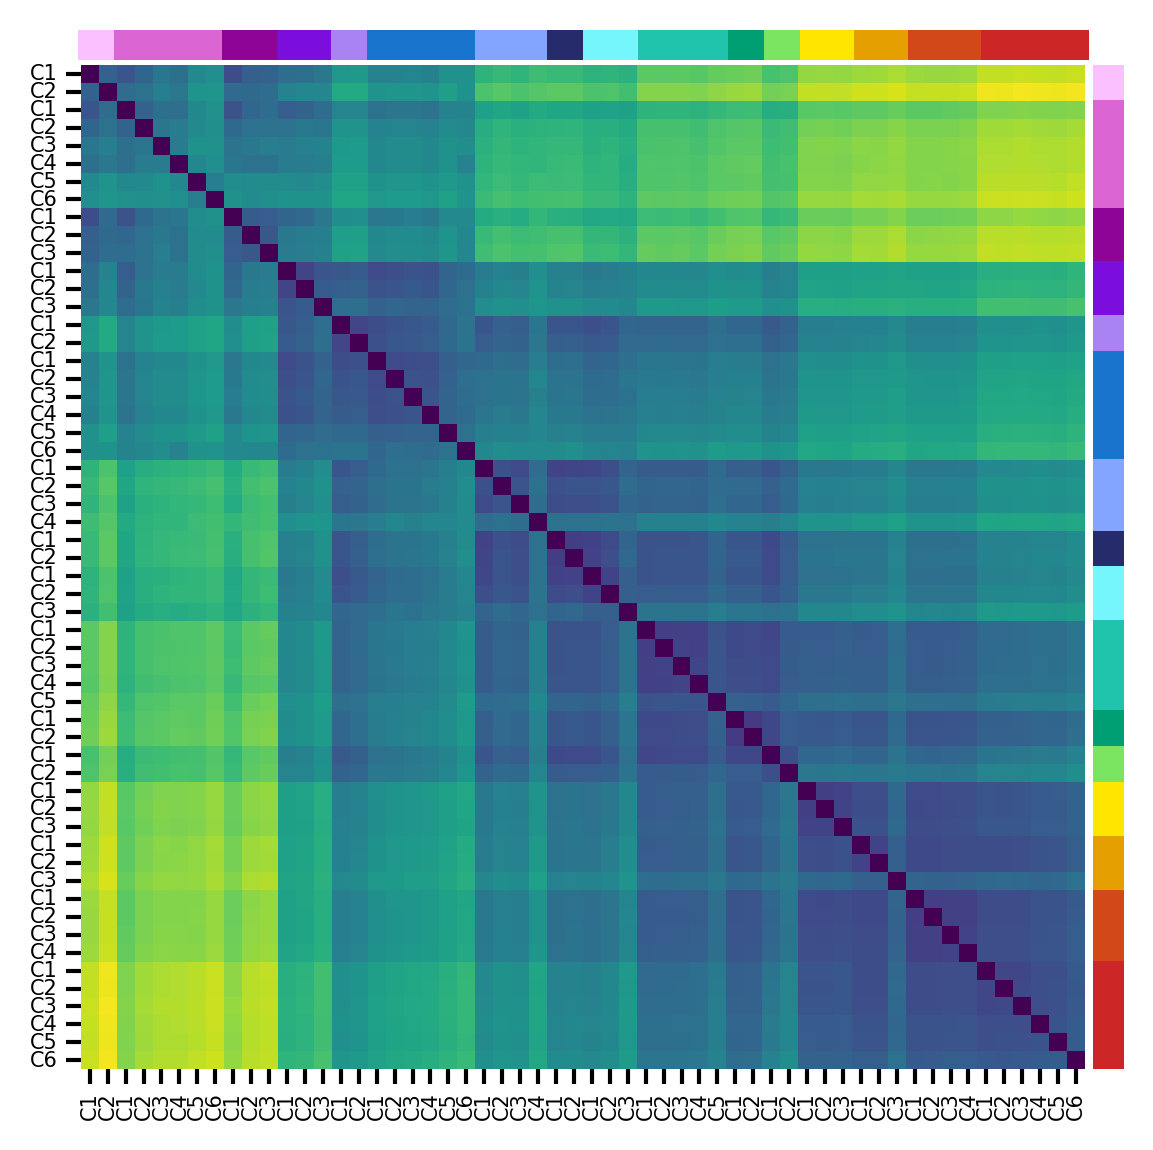

In [6]:
set_theme(figsize=(6, 6))

embryos = [
    "E7.5-R1", "E7.5-R2", "E7.5-R3",
    "E8.0-R1", "E8.0-R2", "E8.0-R3",
    "E8.5-R1", "E8.5-R2", "E8.5-R3",
    "E9.0-R1", "E9.0-R2", "E9.0-R3",
    "E9.5-R1", "E9.5-R2", "E9.5-R3",
    "E10.0-R1",
]
embryo_palette = dict(zip(embryos, reversed(discrete_cmap[17][1:17])))

labels = list(mat.index)
embryo_ids = ["-".join(l.split("-")[:2]) for l in labels]
short_labels = [l.split("-")[-1] for l in labels]
rgba = np.array([mcolors.to_rgba(embryo_palette[e]) for e in embryo_ids])

fig = plt.figure(figsize=(4.5, 4.5), dpi=300)

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1, 0.03],
    height_ratios=[0.03, 1],
    wspace=0.01,
    hspace=0.01,
)

ax_col = fig.add_subplot(gs[0, 0])
ax      = fig.add_subplot(gs[1, 0])
ax_row  = fig.add_subplot(gs[1, 1])
fig.add_subplot(gs[0, 1]).set_axis_off()

sns.heatmap(mat, square=True, cmap="viridis", ax=ax, cbar=False,
            xticklabels=short_labels, yticklabels=short_labels,
            vmin=0, vmax=90)
ax.tick_params(axis="both", labelsize=5)
ax.set_xlabel("")
ax.set_ylabel("")

ax_col.imshow(rgba[np.newaxis, :, :], aspect="auto")
ax_col.set_axis_off()

ax_row.imshow(rgba[:, np.newaxis, :], aspect="auto")
ax_row.set_axis_off()

save_plot("distributional_metrics/between_clones_ot.svg", fig)

In [7]:
print(mat.max().max())
print(mat.min().min())

88.85544906616211
0.0
